### Recommendation System Project

### Problem Statement :

Build your own recommendation system for products on an e-commerce website like Amazon.com. 

### Dataset columns :
First three columns are userId, productId, and ratings and the fourth column is timestamp. You can discard the timestamp column as in this case you may not need to use it.

Source - Amazon Reviews data (http://jmcauley.ucsd.edu/data/amazon/).

 

Dataset Link - https://drive.google.com/file/d/1ClBptsK3V5KgKXtK2GSRzFNAW7GnTPDW/view?usp=sharing

Please do the analysis based on steps( 1 to 8) as given below  using a NEW python notebook:

Steps :

1. Read and explore the given dataset.  ( Rename column/add headers, plot histograms, find data characteristics)
2. Take a subset of the dataset to make it less sparse/ denser. ( For example, keep the users only who has given 50 or more number of ratings )
3. Split the data randomly into train and test dataset. ( For example, split it in 70/30 ratio)
4. Build Popularity Recommender model.
5. Build Collaborative Filtering model.
6. Evaluate both the models. ( Once the model is trained on the training data, it can be used to compute the error (like RMSE)  on predictions made on the test data.) You can also use a different method to evaluate the models.
7. Get top - K ( K = 5) recommendations. Since our goal is to recommend new products to each user based on his/her habits, we will recommend 5 new products.
8. Summarise your insights.
 

Please Note - 

If you are facing any memory issue while working on this project, create a small subset (Let’s say 10% of data) and work on it.

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np

import time
from sklearn.externals import joblib

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from sklearn.model_selection import train_test_split

### 1. Read and explore the given dataset. ( Rename column/add headers, plot histograms, find data characteristics)

In [4]:
#Read rating data from CSV file and  set column name like as given ("User_id","Product_id","Ratings","Timestamp")
column=["user_id","product_id","ratings","timestamp"]
ratings_data_Full = pd.read_csv('ratings_Electronics.csv',header=None,names =column)

In [5]:
#Get shape of the full rating dataset
ratings_data_Full.shape

(7824482, 4)

In the rating full dataset we have 78,24,482 rows and 4 columns.

Since data set is very huge this will give memory issue if we use this full data set. 

Due to that we will use subset of data from full size, let use 50% of random sampling from full dataset, which means we will use just 3912241 rows as sample for this project.

In [6]:
ratings_data_Full.head(5)

,user_id,product_id,ratings,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [7]:
#Drop timestamp column which not required for modeling

ratings_data_Full=ratings_data_Full.drop(columns=['timestamp'])

In [174]:
# ** Get sample of 10% of data from rating full dataset **

#Sample method returns a random sample of items from an axis of object and this object of same type as your caller.
# we can do fraction of axis items and get rows. For example, if frac= .50 then sample method return 10% of rows.
# As said,above we will use 3912241 rows 

rating_df=ratings_data_Full.sample(frac =.50)

In [175]:
rating_df.shape

(3912241, 3)

In [176]:
rating_df.head()

,user_id,product_id,ratings
7003809,A35ZL70KC1TQI1,B00B1V5QRO,1.0
4780712,A1I6SG3D98FZAL,B0058X26OC,5.0
2992913,A3E7R7NKFS5GT1,B00316263Y,4.0
4054691,AEPRAVU6BKDJL,B004E9SWOO,3.0
1821920,A3CXEO9U0I8RMH,B0019EHU8G,5.0


In [177]:
rating_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3912241 entries, 7003809 to 2963099
Data columns (total 3 columns):
user_id       object
product_id    object
ratings       float64
dtypes: float64(1), object(2)
memory usage: 119.4+ MB


In [178]:
#Get Number of unique product in the rating dataset
print("Total Number of Unique Product  : {0}".format(rating_df.product_id.nunique()))

Total Number of Unique Product  : 360590


In [179]:
#Get number of unique user who's given rating
print("Total Number of Unique User who's Given Rating  : {0}".format(rating_df.user_id.nunique()))

Total Number of Unique User who's Given Rating  : 2548776


In [180]:
rating_df.ratings.nunique()

5

In [181]:
rating_df.ratings.value_counts()

5.0    2173661
4.0     742732
1.0     450595
3.0     316723
2.0     228530
Name: ratings, dtype: int64

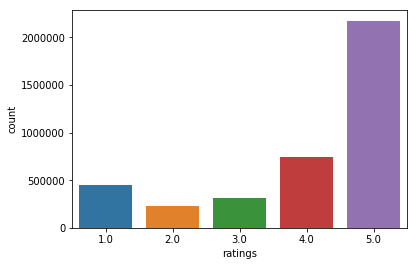

In [182]:
sns.countplot(x="ratings", data=rating_df)

In [183]:
#Drop if any duplicate in the data set
rating_df=rating_df.drop_duplicates(subset=['product_id', 'user_id','ratings'], keep='first')

In [184]:
#Look there is no duplicate in the rating data set
rating_df.shape

(3912241, 3)

### 2. Take a subset of the dataset to make it less sparse/ denser. ( For example, keep the users only who has given 50 or more number of ratings )

In [185]:
user_count =rating_df.user_id.value_counts()
df_user_count = pd.DataFrame(user_count).reset_index()
df_user_count.columns = ['user_id', 'counts']



In [186]:
df_user_count.head(20)

,user_id,counts
0,ADLVFFE4VBT8,256
1,A5JLAU2ARJ0BO,247
2,A3OXHLG6DIBRW8,239
3,A6FIAB28IS79,207
4,A680RUE1FDO8B,204
5,A1ODOGXEYECQQ8,200
6,A2AY4YUOX2N1BQ,174
7,ARBKYIVNYWK3C,156
8,A36K2N527TXXJN,154
9,A22CW0ZHY3NJH8,152


In [187]:
#Get unique user who has given 50 or more ratings
df_user_count=df_user_count[df_user_count.counts >=50]

In [188]:
#Get unique user 
rating_df_subset=rating_df[rating_df.user_id.isin(df_user_count.user_id)]

In [189]:
rating_df_subset.shape

(21885, 3)

In [190]:
rating_df_subset.head()

,user_id,product_id,ratings
3396240,A1U5NWJOYH2QQH,B003JNEVRI,4.0
4346410,A37CEYB95LK6R6,B004PW04B4,5.0
1532553,A11KZ906QD08C5,B000YIYNOW,5.0
3287221,A2I357I10ZY7CI,B003E6D9FK,5.0
7087062,A5KMMY627T3W,B00BF6HVG4,5.0


In [209]:
print('Number of users who have rated 50 or more items =', len(rating_df_subset))
print('Number of unique USERS in final data = ', rating_df_subset['user_id'].nunique())
print('Number of unique PRODUCT in final data = ', rating_df_subset['product_id'].nunique())

Number of users who have rated 50 or more items = 21885
Number of unique USERS in final data =  283
Number of unique PRODUCT in final data =  13597


### 3. Split the data randomly into train and test dataset. ( For example, split it in 70/30 ratio)

In [192]:
train_data, test_data = train_test_split(rating_df_subset, test_size = 0.30, random_state=0)
print(train_data.head(5))

                user_id  product_id  ratings
6400301  A17BUUBOU0598B  B008X9Z8NE      3.0
985451   A1F9Z42CFF9IAY  B000H4CLXS      5.0
5227126  A23GFTVIETX7DS  B005X64OQ2      5.0
487633   A1V3TRGWOMA8LC  B0002L5R78      5.0
1212058    AONUCJBC85BL  B000NLLXUM      4.0


In [193]:
print("Train data shape : {0}".format(train_data.shape))

Train data shape : (15319, 3)


In [194]:
print("Test data shape : {0}".format(test_data.shape))

Test data shape : (6566, 3)


### 4. Build Popularity Recommender model

In [195]:
#Class for Popularity based Recommender System model
class popularity_recommender_py():
    def __init__(self):
        self.train_data = None
        self.user_id = None
        self.item_id = None
        self.popularity_recommendations = None
        
        
    #Create the popularity based recommender system model
    def create(self, train_data, user_id, item_id):
        self.train_data = train_data
        self.user_id = user_id
        self.item_id = item_id

        #Get a count of user_ids for each unique product as recommendation score
        train_data_grouped = train_data.groupby([self.item_id]).agg({self.user_id: 'count'}).reset_index()
        train_data_grouped.rename(columns = {self.user_id: "score"},inplace=True)
        #Sort the products based upon recommendation score
        train_data_sort = train_data_grouped.sort_values(by=["score", self.item_id], ascending=[0,1])
    
        #Generate a recommendation rank based upon score
        train_data_sort['Rank'] = train_data_sort['score'].rank(ascending=0, method='first')
        
        #Get the top  recommendations
        self.popularity_recommendations = train_data_sort

    #Use the popularity based recommender system model to
    #make recommendations
    def recommend(self, user_id, k=10 ):    
        user_recommendations = self.popularity_recommendations
        
        #Add user_id column for which the recommendations are being generated
        user_recommendations[self.user_id] = user_id
    
        #Bring user_id column to the front
        cols = user_recommendations.columns.tolist()
        cols = cols[-1:] + cols[:-1]
        user_recommendations = user_recommendations[cols]
        
        return user_recommendations.head(k)




In [196]:
pm = popularity_recommender_py()
pm.create(train_data, 'user_id', 'product_id')

In [197]:
users=train_data.user_id.unique()

In [210]:
user_id = users[50]
#Get Top 5 recommended product
pm.recommend(user_id,5)

,user_id,product_id,score,Rank
8121,A23NSKTMSPPBTR,B0088CJT4U,29,1.0
4621,A23NSKTMSPPBTR,B002R5AM7C,19,2.0
8069,A23NSKTMSPPBTR,B00829THK0,19,3.0
4923,A23NSKTMSPPBTR,B0034CL2ZI,17,4.0
5243,A23NSKTMSPPBTR,B003ES5ZUU,17,5.0


In [211]:
user_id = users[51]
#Get Top 10 recommended product
pm.recommend(user_id)

,user_id,product_id,score,Rank
8121,A3R4794K2RVU1S,B0088CJT4U,29,1.0
4621,A3R4794K2RVU1S,B002R5AM7C,19,2.0
8069,A3R4794K2RVU1S,B00829THK0,19,3.0
4923,A3R4794K2RVU1S,B0034CL2ZI,17,4.0
5243,A3R4794K2RVU1S,B003ES5ZUU,17,5.0
6057,A3R4794K2RVU1S,B004CLYEDC,17,6.0
6059,A3R4794K2RVU1S,B004CLYEFK,17,7.0
4728,A3R4794K2RVU1S,B002V88HFE,16,8.0
6058,A3R4794K2RVU1S,B004CLYEE6,16,9.0
6502,A3R4794K2RVU1S,B004T9RR6I,16,10.0


### 5. Build Collaborative Filtering model.

In [200]:
#Class for Item similarity based Recommender System model
class item_similarity_recommender_py():
    def __init__(self):
        self.train_data = None
        self.user_id = None
        self.item_id = None
        self.cooccurence_matrix = None
        self.items_dict = None
        self.rev_items_dict = None
        self.item_similarity_recommendations = None
        
    #Get unique items (products) corresponding to a given user
    def get_user_items(self, user):
        user_data = self.train_data[self.train_data[self.user_id] == user]
        user_items = list(user_data[self.item_id].unique())
        
        return user_items
        
    #Get unique users for a given item (product)
    def get_item_users(self, item):
        item_data = self.train_data[self.train_data[self.item_id] == item]
        item_users = set(item_data[self.user_id].unique())
            
        return item_users
        
    #Get unique items (products) in the training data
    def get_all_items_train_data(self):
        all_items = list(self.train_data[self.item_id].unique())
            
        return all_items
        
    #Construct cooccurence matrix
    def construct_cooccurence_matrix(self, user_items, all_items):
            
        ####################################
        #Get users for all products in user_items.
        ####################################
        user_items_users = []        
        for i in range(0, len(user_items)):
            user_items_users.append(self.get_item_users(user_items[i]))
            
        ###############################################
        #Initialize the item cooccurence matrix of size 
        #len(user_items) X len(items)
        ###############################################
        cooccurence_matrix = np.matrix(np.zeros(shape=(len(user_items), len(all_items))), float)
           
        #############################################################
        #Calculate similarity between user items and all unique items
        #in the training data
        #############################################################
        for i in range(0,len(all_items)):
            #Calculate unique listeners (users) of item (product) i
            items_i_data = self.train_data[self.train_data[self.item_id] == all_items[i]]
            users_i = set(items_i_data[self.user_id].unique())
            
            for j in range(0,len(user_items)):       
                    
                #Get unique listeners (users) of item (product) j
                users_j = user_items_users[j]
                    
                #Calculate intersection of listeners of items i and j
                users_intersection = users_i.intersection(users_j)
                
                #Calculate cooccurence_matrix[i,j] as Jaccard Index
                if len(users_intersection) != 0:
                    #Calculate union of listeners of items i and j
                    users_union = users_i.union(users_j)
                    
                    cooccurence_matrix[j,i] = float(len(users_intersection))/float(len(users_union))
                else:
                    cooccurence_matrix[j,i] = 0
                    
        
        return cooccurence_matrix

    
    #Use the cooccurence matrix to make top recommendations
    def generate_top_recommendations(self, user, cooccurence_matrix, all_items, user_items):
        print("Non zero values in cooccurence_matrix :%d" % np.count_nonzero(cooccurence_matrix))
        
        #Calculate a weighted average of the scores in cooccurence matrix for all user items.
        user_sim_scores = cooccurence_matrix.sum(axis=0)/float(cooccurence_matrix.shape[0])
        user_sim_scores = np.array(user_sim_scores)[0].tolist()
 
        #Sort the indices of user_sim_scores based upon their value
        #Also maintain the corresponding score
        sort_index = sorted(((e,i) for i,e in enumerate(list(user_sim_scores))), reverse=True)
    
        #Create a dataframe from the following
        columns = ['user_id', 'product_id', 'score', 'rank']
        #index = np.arange(1) # array of numbers for the number of samples
        df = pd.DataFrame(columns=columns)
         
        #Fill the dataframe with top 10 item based recommendations
        rank = 1 
        for i in range(0,len(sort_index)):
            if ~np.isnan(sort_index[i][0]) and all_items[sort_index[i][1]] not in user_items:
                df.loc[len(df)]=[user,all_items[sort_index[i][1]],sort_index[i][0],rank]
                rank = rank+1
        
        #Handle the case where there are no recommendations
        if df.shape[0] == 0:
            print("The current user has no products for training the item similarity based recommendation model.")
            return -1
        else:
            return df
 
    #Create the item similarity based recommender system model
    def create(self, train_data, user_id, item_id):
        self.train_data = train_data
        self.user_id = user_id
        self.item_id = item_id

    #Use the item similarity based recommender system model to
    #make recommendations
    def recommend(self, user,k=10):
        
        ########################################
        #A. Get all unique products for this user
        ########################################
        user_items = self.get_user_items(user)    
            
        print("No. of unique products for the user: %d" % len(user_items))
        
        ######################################################
        #B. Get all unique items (products) in the training data
        ######################################################
        all_items = self.get_all_items_train_data()
        
        print("no. of unique products in the training set: %d" % len(all_items))
         
        ###############################################
        #C. Construct item cooccurence matrix of size 
        #len(user_items) X len(items)
        ###############################################
        cooccurence_matrix = self.construct_cooccurence_matrix(user_items, all_items)
        
        #######################################################
        #D. Use the cooccurence matrix to make recommendations
        #######################################################
        df_recommendations = self.generate_top_recommendations(user, cooccurence_matrix, all_items, user_items)
                
        return df_recommendations.head(k)
    
    #Get similar items to given items
    def get_similar_items(self, item_list):
        
        user_items = item_list
        
        ######################################################
        #B. Get all unique items (products) in the training data
        ######################################################
        all_items = self.get_all_items_train_data()
        
        print("no. of unique products in the training set: %d" % len(all_items))
         
        ###############################################
        #C. Construct item cooccurence matrix of size 
        #len(user_items) X len(items)
        ###############################################
        cooccurence_matrix = self.construct_cooccurence_matrix(user_items, all_items)
        
        #######################################################
        #D. Use the cooccurence matrix to make recommendations
        #######################################################
        user = ""
        df_recommendations = self.generate_top_recommendations(user, cooccurence_matrix, all_items, user_items)
         
        return df_recommendations

In [201]:
#Create an instance of item similarity based recommender class
is_model = item_similarity_recommender_py()
is_model.create(train_data, 'user_id', 'product_id')

In [202]:
#Print the products for the user in training data
user_id = users[50]
user_items = is_model.get_user_items(user_id)
#
print("------------------------------------------------------------------------------------")
print("Training data products for the user userid: %s:" % user_id)
print("------------------------------------------------------------------------------------")

for user_item in user_items:
    print(user_item)

print("----------------------------------------------------------------------")
print("Recommendation process going on:")
print("----------------------------------------------------------------------")

#Recommend products for the user using personalized model
is_model.recommend(user_id,k=5)

------------------------------------------------------------------------------------
Training data products for the user userid: A23NSKTMSPPBTR:
------------------------------------------------------------------------------------
B001S4OTS6
B0027AGK3M
B00009V4HF
B004WB8EYM
B0001AOF96
B0034CL2ZI
B0000AC88K
B002TLTE6Y
B00EUFP39E
B00DPOHIK8
B001J8TBNO
B00BCXF4HI
B00CXADBRY
B000UODATY
B0019D6H2M
B007M4Z60Q
B000M17AVO
B00EUUKVXM
B004CLYEFK
B00DR0B31U
B00FZ9SJLS
B0002Y5WW0
B00EAR8S76
B000HAR8UI
B008ISKDL2
B004TKTOWC
B001MSZBNA
B004Z9XG0I
B0000ANEYY
B00213FX38
B000O7K4LO
B00BQ4F9ZA
B00BFIKEPC
B00HG1L334
B00G6CLN3Y
B00505F01E
B000YJPU0M
B0040Q4TLQ
B0049SIPBK
B000UNRSZM
B00DQZTJKI
B003H37QZ4
B000068O3C
----------------------------------------------------------------------
Recommendation process going on:
----------------------------------------------------------------------
No. of unique products for the user: 43
no. of unique products in the training set: 10448
Non zero values in cooccurence_m

,user_id,product_id,score,rank
0,A23NSKTMSPPBTR,B001NTDGQC,0.020155,1
1,A23NSKTMSPPBTR,B002HEWA28,0.020155,2
2,A23NSKTMSPPBTR,B002C1BHIO,0.020155,3
3,A23NSKTMSPPBTR,B001U3ZVQ4,0.018309,4
4,A23NSKTMSPPBTR,B004J4VYEY,0.017700,5


### We can also apply the model to find similar products to any products in the dataset

In [203]:
is_model.get_similar_items(['B003VAM32E'])

no. of unique products in the training set: 10448
Non zero values in cooccurence_matrix :118


,user_id,product_id,score,rank
0,,B004WDIV8E,0.5,1
1,,B001IZZ7MM,0.5,2
2,,B004KPLLJA,0.5,3
3,,B0046A8R3M,0.5,4
4,,B0068INTCY,0.5,5
5,,B00HSGFPC2,0.5,6
6,,B005FT3AOE,0.5,7
7,,B000052WM4,0.5,8
8,,B0055Q7BR4,0.5,9
9,,B004BDORCO,0.5,10


### 6. Evaluate both the models. 
( Once the model is trained on the training data, it can be used to compute the error (like RMSE) on predictions made on the test data.) 

You can also use a different method to evaluate the models.

In [204]:
#Class to calculate precision and recall

import random

class precision_recall_calculator():
    
    def __init__(self, test_data, train_data, pm, is_model):
        self.test_data = test_data
        self.train_data = train_data
        self.user_test_sample = None
        self.model1 = pm
        self.model2 = is_model
        
        self.ism_training_dict = dict()
        self.pm_training_dict = dict()
        self.test_dict = dict()
    
    #Method to return random percentage of values from a list
    def remove_percentage(self, list_a, percentage):
        k = int(len(list_a) * percentage)
        random.seed(0)
        indicies = random.sample(range(len(list_a)), k)
        new_list = [list_a[i] for i in indicies]
    
        return new_list
    
    #Create a test sample of users for use in calculating precision
    #and recall
    def create_user_test_sample(self, percentage):
        #Find users common between training and test set
        users_test_and_training = list(set(self.test_data['user_id'].unique()).intersection(set(self.train_data['user_id'].unique())))
        print("Length of user_test_and_training:%d" % len(users_test_and_training))

        #Take only random user_sample of users for evaluations
        self.users_test_sample = self.remove_percentage(users_test_and_training, percentage)

        print("Length of user sample:%d" % len(self.users_test_sample))
        
    #Method to generate recommendations for users in the user test sample
    def get_test_sample_recommendations(self):
        #For these test_sample users, get top 10 recommendations from training set
        #self.ism_training_dict = {}
        #self.pm_training_dict = {}

        #self.test_dict = {}

        for user_id in self.users_test_sample:
            #Get items for user_id from item similarity model
            print("Getting recommendations for user:%s" % user_id)
            user_sim_items = self.model2.recommend(user_id)
            print(user_sim_items)
            self.ism_training_dict[user_id] = list(user_sim_items["product_id"])
    
            #Get items for user_id from popularity model
            user_sim_items = self.model1.recommend(user_id)
            print(user_sim_items)
            self.pm_training_dict[user_id] = list(user_sim_items["product_id"])
    
            #Get items for user_id from test_data
            test_data_user = self.test_data[self.test_data['user_id'] == user_id]
            self.test_dict[user_id] = set(test_data_user['product_id'].unique() )
            print(self.test_dict[user_id])
            
    #Method to calculate the precision and recall measures
    def calculate_precision_recall(self):
        #Create cutoff list for precision and recall calculation
        cutoff_list = list(range(1,11))


        #For each distinct cutoff:
        #    1. For each distinct user, calculate precision and recall.
        #    2. Calculate average precision and recall.

        ism_avg_precision_list = []
        ism_avg_recall_list = []
        pm_avg_precision_list = []
        pm_avg_recall_list = []


        num_users_sample = len(self.users_test_sample)
        for N in cutoff_list:
            ism_sum_precision = 0
            ism_sum_recall = 0
            pm_sum_precision = 0
            pm_sum_recall = 0
            ism_avg_precision = 0
            ism_avg_recall = 0
            pm_avg_precision = 0
            pm_avg_recall = 0

            for user_id in self.users_test_sample:
                ism_hitset = self.test_dict[user_id].intersection(set(self.ism_training_dict[user_id][0:N]))
                pm_hitset = self.test_dict[user_id].intersection(set(self.pm_training_dict[user_id][0:N]))
                testset = self.test_dict[user_id]
        
                pm_sum_precision += float(len(pm_hitset))/float(N)
                pm_sum_recall += float(len(pm_hitset))/float(len(testset))

                ism_sum_precision += float(len(ism_hitset))/float(len(testset))
                ism_sum_recall += float(len(ism_hitset))/float(N)
        
            pm_avg_precision = pm_sum_precision/float(num_users_sample)
            pm_avg_recall = pm_sum_recall/float(num_users_sample)
    
            ism_avg_precision = ism_sum_precision/float(num_users_sample)
            ism_avg_recall = ism_sum_recall/float(num_users_sample)

            ism_avg_precision_list.append(ism_avg_precision)
            ism_avg_recall_list.append(ism_avg_recall)
    
            pm_avg_precision_list.append(pm_avg_precision)
            pm_avg_recall_list.append(pm_avg_recall)
            
        return (pm_avg_precision_list, pm_avg_recall_list, ism_avg_precision_list, ism_avg_recall_list)
     

    #A wrapper method to calculate all the evaluation measures
    def calculate_measures(self, percentage):
        #Create a test sample of users
        self.create_user_test_sample(percentage)
        
        #Generate recommendations for the test sample users
        self.get_test_sample_recommendations()
        
        #Calculate precision and recall at different cutoff values
        #for popularity mode (pm) as well as item similarity model (ism)
        
        return self.calculate_precision_recall()
        #return (pm_avg_precision_list, pm_avg_recall_list, ism_avg_precision_list, ism_avg_recall_list)    

In [205]:
start = time.time()

#Define what percentage of users to use for precision recall calculation
user_sample = 0.01

#Instantiate the precision_recall_calculator class
pr = precision_recall_calculator(test_data, train_data, pm, is_model)

#Call method to calculate precision and recall values
(pm_avg_precision_list, pm_avg_recall_list, ism_avg_precision_list, ism_avg_recall_list) = pr.calculate_measures(user_sample)

end = time.time()
print(end - start)

Length of user_test_and_training:283
Length of user sample:2
Getting recommendations for user:A2V5M5EJPOD2IU
No. of unique products for the user: 51
no. of unique products in the training set: 10448
Non zero values in cooccurence_matrix :10209
          user_id  product_id     score rank
0  A2V5M5EJPOD2IU  B00DQZSEWM  0.022845    1
1  A2V5M5EJPOD2IU  B006T7KQDO  0.020990    2
2  A2V5M5EJPOD2IU  B000MYPPPE  0.020519    3
3  A2V5M5EJPOD2IU  B008MF3Y2G  0.020121    4
4  A2V5M5EJPOD2IU  B001IWOBA4  0.019943    5
5  A2V5M5EJPOD2IU  B00GFF4UFK  0.019608    6
6  A2V5M5EJPOD2IU  B00BJOZNV2  0.019608    7
7  A2V5M5EJPOD2IU  B00DY7WPF4  0.019608    8
8  A2V5M5EJPOD2IU  B001U3ZH7W  0.019608    9
9  A2V5M5EJPOD2IU  B00F705VHU  0.019608   10
             user_id  product_id  score  Rank
8121  A2V5M5EJPOD2IU  B0088CJT4U     29   1.0
4621  A2V5M5EJPOD2IU  B002R5AM7C     19   2.0
8069  A2V5M5EJPOD2IU  B00829THK0     19   3.0
4923  A2V5M5EJPOD2IU  B0034CL2ZI     17   4.0
5243  A2V5M5EJPOD2IU  B003ES5ZU

In [206]:
import pylab as pl

#Method to generate precision and recall curve
def plot_precision_recall(m1_precision_list, m1_recall_list, m1_label, m2_precision_list, m2_recall_list, m2_label):
    pl.clf()    
    pl.plot(m1_recall_list, m1_precision_list, label=m1_label)
    pl.plot(m2_recall_list, m2_precision_list, label=m2_label)
    pl.xlabel('Recall')
    pl.ylabel('Precision')
    pl.ylim([0.0, 0.2])
    pl.xlim([0.0, 0.2])
    pl.title('Precision-Recall curve')
    #pl.legend(loc="upper right")
    pl.legend(loc=9, bbox_to_anchor=(0.5, -0.2))
    pl.show()

Plotting precision recall curves.


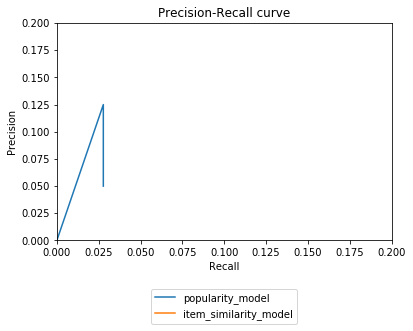

In [207]:
print("Plotting precision recall curves.")

plot_precision_recall(pm_avg_precision_list, pm_avg_recall_list, "popularity_model",
                      ism_avg_precision_list, ism_avg_recall_list, "item_similarity_model")

### 7. Get top - K ( K = 5) recommendations. Since our goal is to recommend new products to each user based on his/her habits, we will recommend 5 new products.

In [208]:
#Print the products for the user in training data
user_id = users[50]

print("----------------------------------------------------------------------")
print("Collaborative Filtering model - Recommendation for User {0}".format(user_id))
print("----------------------------------------------------------------------")

#Recommend products for the user using personalized model
print(is_model.recommend(user_id,k=5))
print("=========================================================================")


print("----------------------------------------------------------------------")
print("Popularity model - Recommendation for User {0}".format(user_id))
print("----------------------------------------------------------------------")

#Recommend products for the user using Popularity model
print(pm.recommend(user_id,k=5))
print("=========================================================================")

----------------------------------------------------------------------
Collaborative Filtering model - Recommendation for User A23NSKTMSPPBTR
----------------------------------------------------------------------
No. of unique products for the user: 43
no. of unique products in the training set: 10448
Non zero values in cooccurence_matrix :6900
          user_id  product_id     score rank
0  A23NSKTMSPPBTR  B001NTDGQC  0.020155    1
1  A23NSKTMSPPBTR  B002HEWA28  0.020155    2
2  A23NSKTMSPPBTR  B002C1BHIO  0.020155    3
3  A23NSKTMSPPBTR  B001U3ZVQ4  0.018309    4
4  A23NSKTMSPPBTR  B004J4VYEY  0.017700    5
----------------------------------------------------------------------
Popularity model - Recommendation for User A23NSKTMSPPBTR
----------------------------------------------------------------------
             user_id  product_id  score  Rank
8121  A23NSKTMSPPBTR  B0088CJT4U     29   1.0
4621  A23NSKTMSPPBTR  B002R5AM7C     19   2.0
8069  A23NSKTMSPPBTR  B00829THK0     19   3.0

### 8.Summarise your insights.

1. In the given orginal data set having 7824482 rows and 4 Column.
2. From the orginal Dataset we have taken only 50% random sampling data due to memory issue and count of row is 3912241.
3. As per reqeuest we have taken "who have rated 50 or more items" for modeling and this final dataset rowcount is 21885.
4. Number of unique USERS in final data =  283
5. Number of unique PRODUCT in final data =  13597
6. We have tried Popularity based Recommender model and Collaborative Filtering model using final dataset
7. As per our conclusion, The Popularity based model has recommended the same set of  products to the user index 50 & 51 but Collaborative Filtering based model has recommended entire different list based on the user past purchase history.